#***IMDB Movies Dataset***


Dataset extracted from IMDb (the world's largest movie website).

Contains approximately 1,000 movies with attributes such as title, release year, genre, audience and critic ratings, box office revenue, etc.


In [179]:
# --- Libraries ---

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import seaborn as sns

print('Libraries imported')

Libraries imported


In [180]:
# --- Load Data ---
df = pd.read_csv('imdb_top_1000.csv')

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns\n")

Dataset loaded: 1000 rows x 16 columns



#   Initial Checks

In [181]:
# Check the first few rows
print("\nFirst 5 rows:")
print(df.head())

print("\nSummary on columns names, nulls and data types\n")
print(df.info())


First 5 rows:
                                         Poster_Link  \
0  https://m.media-amazon.com/images/M/MV5BMDFkYT...   
1  https://m.media-amazon.com/images/M/MV5BM2MyNj...   
2  https://m.media-amazon.com/images/M/MV5BMTMxNT...   
3  https://m.media-amazon.com/images/M/MV5BMWMwMG...   
4  https://m.media-amazon.com/images/M/MV5BMWU4N2...   

               Series_Title Released_Year Certificate  Runtime  \
0  The Shawshank Redemption          1994           A  142 min   
1             The Godfather          1972           A  175 min   
2           The Dark Knight          2008          UA  152 min   
3    The Godfather: Part II          1974           A  202 min   
4              12 Angry Men          1957           U   96 min   

                  Genre  IMDB_Rating  \
0                 Drama          9.3   
1          Crime, Drama          9.2   
2  Action, Crime, Drama          9.0   
3          Crime, Drama          9.0   
4          Crime, Drama          9.0   

          

In [182]:
print("\nDataset columns:")
print(df.columns)

#names ok,  Snake_case


Dataset columns:
Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')


In [183]:
# == Removing duplicates if needed ==

# == Count duplicates==
print(f'\nDuplicate rows: {df.duplicated().sum()}')

print(f'\nThere are no duplicate records in the dataframe')


Duplicate rows: 0

There are no duplicate records in the dataframe


In [184]:
#== Missing values ==

missing_summary = (
    pd.DataFrame({
        'missing_count': df.isna().sum(),
        'missing_pct': df.isna().mean().mul(100).round(2)
    })
    .sort_values('missing_pct', ascending=False)
)


missing_summary = missing_summary.loc[missing_summary['missing_pct'] > 0] \
                                   .sort_values('missing_pct', ascending=False)

missing_summary

# For now, I've decided not to allocate lost values.  I will act as the analysis requires.


,missing_count,missing_pct
Gross,169,16.9
Meta_score,157,15.7
Certificate,101,10.1


#Data Preprocessing | Data Cleaning & Type Conversion

In [185]:
# Convert Released_Year to numeric
df["Released_Year"] = pd.to_numeric(df["Released_Year"], errors="coerce")

# Check
print(f"Null values ​​after conversion: {df['Released_Year'].isna().sum()}")

df[df['Released_Year'].isna()]

'''
According to wikipedia, Apollo 13 was released in 1995
https://en.wikipedia.org/wiki/Apollo_13_(film)#:~:text=Apollo%2013%20is%20a%201995%20American%20docudrama%20film,Paxton%2C%20Gary%20Sinise%2C%20Ed%20Harris%20and%20Kathleen%20Quinlan.
'''

# Series_Title = Apollo 13	 --> Released_Year = 1995

df["Released_Year"] = df["Released_Year"].fillna(1995).astype('Int64')  # fill missing + convertion to int


Null values ​​after conversion: 1


In [186]:
print (df[df["Series_Title"] == "Apollo 13"] ) # --> now Released_Year = 1995

# Check
print(f"\nNull values ​​after conversion: {df['Released_Year'].isna().sum()}")

                                           Poster_Link Series_Title  \
966  https://m.media-amazon.com/images/M/MV5BNjEzYj...    Apollo 13   

     Released_Year Certificate  Runtime                      Genre  \
966           1995           U  140 min  Adventure, Drama, History   

     IMDB_Rating                                           Overview  \
966          7.6  NASA must devise a strategy to return Apollo 1...   

     Meta_score    Director      Star1        Star2        Star3        Star4  \
966        77.0  Ron Howard  Tom Hanks  Bill Paxton  Kevin Bacon  Gary Sinise   

     No_of_Votes        Gross  
966       269197  173,837,933  

Null values ​​after conversion: 0


In [187]:
# == convert data types as needed ==

# Categorical columns
categorical_cols = ['Certificate', 'Genre', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Runtime: extract number of minutes
df['Runtime_min'] = df['Runtime'].str.extract(r'(\d+)')
df['Runtime_min'] = df['Runtime_min'].astype('Int64')

# Numeric columns
df['IMDB_Rating'] = df['IMDB_Rating'].astype('float64')
df['Meta_score'] = df['Meta_score'].astype('Int64')

# Remove commas and convert Gross to Int64
df['Gross'] = df['Gross'].str.replace(',', '', regex=True).astype('Int64')

# No_of_Votes: if it has commas, remove and convert
df['No_of_Votes'] = df['No_of_Votes'].astype('Int32')


# Poster_Link, Series_Title, Overview remain object


In [188]:
#check

df.dtypes

,0
Poster_Link,object
Series_Title,object
Released_Year,Int64
Certificate,category
Runtime,object
Genre,category
IMDB_Rating,float64
Overview,object
Meta_score,Int64
Director,category


In [189]:
# ======================================
#  Quantitative vs Qualitative
# ======================================

quantitative = df.select_dtypes(include='number').columns
qualitative = df.select_dtypes(exclude='number').columns
print(f"Quantitative columns: {list(quantitative)}")
print(f"Qualitative columns: {list(qualitative)}")

Quantitative columns: ['Released_Year', 'IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross', 'Runtime_min']
Qualitative columns: ['Poster_Link', 'Series_Title', 'Certificate', 'Runtime', 'Genre', 'Overview', 'Director', 'Star1', 'Star2', 'Star3', 'Star4']


In [190]:
# ======================================
# Plot Style Defaults
# ======================================

#  Matplotlib/Seaborn plots appear inside the notebook, right below the cell where you generate them.
%matplotlib inline

sns.set_context("paper", font_scale=0.8)

sns.set_style("whitegrid")

sns.set_palette("Set2")

# Default size of all figures
plt.rcParams["figure.figsize"] = (6,4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["lines.linewidth"] = 2
plt.rcParams["lines.markersize"] = 4
plt.rcParams["figure.dpi"] = 100   # resolution

sns.despine()  # Remove borders

plt.tight_layout()


<Figure size 600x400 with 0 Axes>

# Exploratory Analysis

3. Rating Trends Over Years:

 * Create a line plot with Matplotlib showing trends in IMDB_Rating over the years.

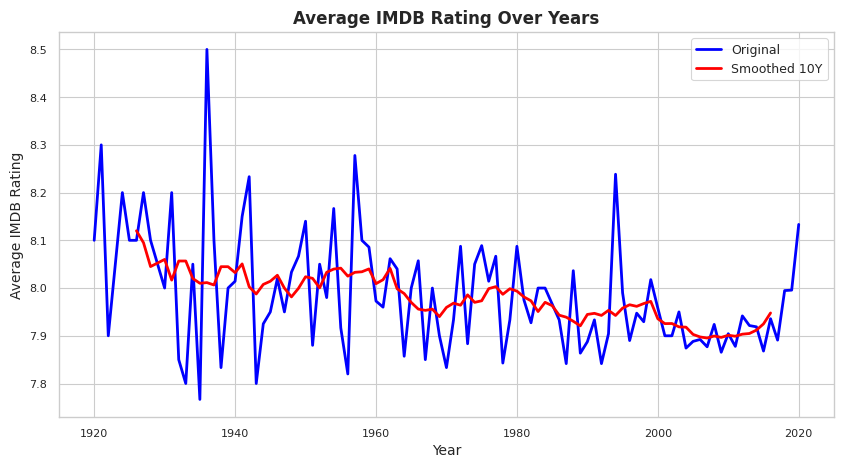

In [191]:
# Group by year
rating_by_year = df.groupby("Released_Year")["IMDB_Rating"].mean()

plt.figure(figsize=(10,5))

plt.plot(rating_by_year.index, rating_by_year.values, label="Original", color="blue")

# Smoothed line with 10-year rolling window
smoothed = rating_by_year.rolling(window=10, center=True).mean()
plt.plot(rating_by_year.index, smoothed.values, label="Smoothed 10Y", color="red", linewidth=2)

plt.title("Average IMDB Rating Over Years")
plt.xlabel("Year")
plt.ylabel("Average IMDB Rating")
plt.legend()
plt.show()


4. Genre Popularity Analysis:

 * Generate a Seaborn bar plot to compare the number of movies across different genres.

In [192]:
genre_check= df["Genre"].unique()
print(genre_check)



['Drama', 'Crime, Drama', 'Action, Crime, Drama', 'Action, Adventure, Drama', 'Biography, Drama, History', ..., 'Action, Adventure, Family', 'Action, Crime, Mystery', 'Animation, Drama, Romance', 'Drama, War, Western', 'Adventure, Comedy, War']
Length: 202
Categories (202, object): ['Action, Adventure', 'Action, Adventure, Biography',
                           'Action, Adventure, Comedy', 'Action, Adventure, Crime', ...,
                           'Mystery, Sci-Fi, Thriller', 'Mystery, Thriller', 'Thriller', 'Western']


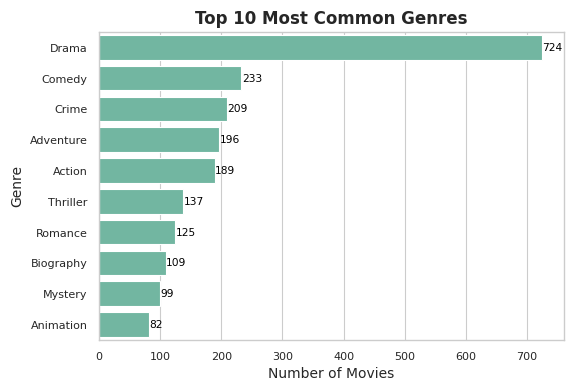

In [193]:
# Split genres
genre_series = df["Genre"].str.split(", ", expand=True).stack()

# Count genres
genre_counts = genre_series.value_counts().head(10)

ax = sns.barplot(x=genre_counts.values, y=genre_counts.index )

# count at the end of each bar
for i, v in enumerate(genre_counts.values):
    ax.text(v + 1, i, str(v), color='black', va='center')

plt.title("Top 10 Most Common Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

5. Director’s Impact on Ratings:

* Use a Matplotlib scatter plot to examine the relationship between directors and movie ratings.

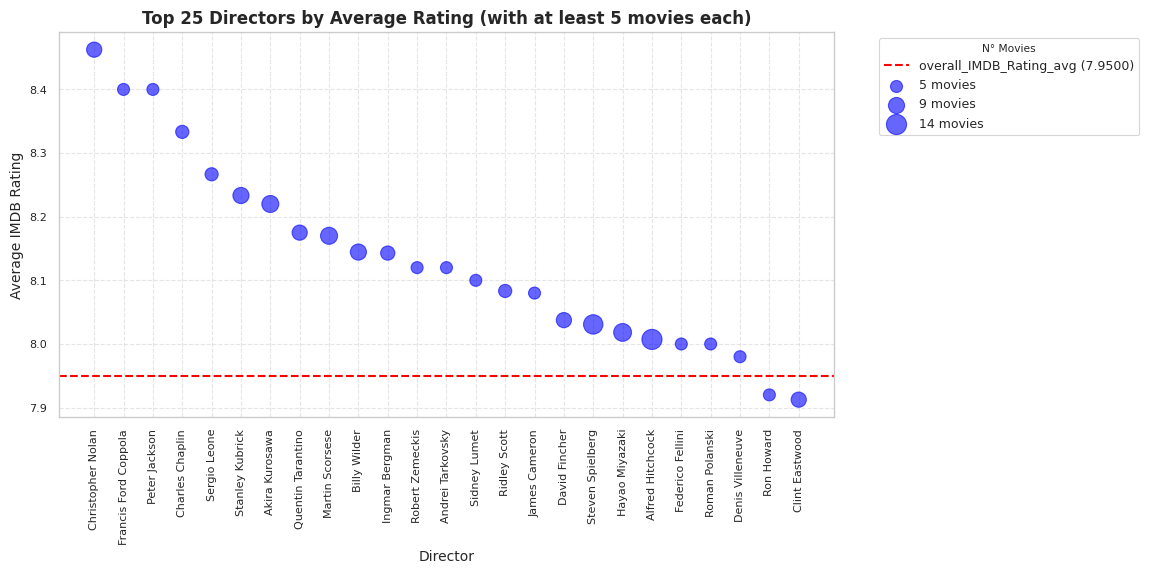

In [194]:
# how many films each director has
director_counts = df["Director"].value_counts()

# Filter directors with at least 5 films
directors_min5 = director_counts[director_counts >= 5].index

# Calculate the average for only those directors
rating_by_director = (
    df[df["Director"].isin(directors_min5)]
      .groupby("Director", observed=True)["IMDB_Rating"]
      .mean())

# maximum 25 directors sorted by average
rating_by_director = rating_by_director.sort_values(ascending=False).head(25)

# Size proportional to the number of movies
sizes = director_counts[rating_by_director.index] * 15  #15 as scaling factor

# Overall average IMDB Rating
overall_mean = df["IMDB_Rating"].mean().round(2)  # 7.9500

# Chart
plt.figure(figsize=(10,5))
plt.scatter(rating_by_director.index, rating_by_director.values, s=sizes, color='blue', alpha=0.6)

plt.xticks(rotation=90)
plt.xlabel("Director")
plt.ylabel("Average IMDB Rating")
plt.title("Top 25 Directors by Average Rating (with at least 5 movies each)")

# Red dotted horizontal line
plt.axhline(y=overall_mean, color='red', linestyle='--', linewidth=1.5, label=f"overall_IMDB_Rating_avg ({overall_mean:.4f})")

plt.grid(True, linestyle='--', alpha=0.5)  # dotted and semi-transparent lines

# legend for sizes
unique_counts = np.linspace(min(director_counts[rating_by_director.index]),
                            max(director_counts[rating_by_director.index]), 3, dtype=int)

for count in unique_counts:
    plt.scatter([], [], s=count*15, color='blue', alpha=0.6, label=f"{count} movies")


plt.legend(title="N° Movies", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

6. Star Power Analysis

 * Employ a Seaborn pairplot to explore relationships involving Stars and their impact on IMDB_Rating and Gross.

In [195]:
# analysing Gross

print(f'Missing in Gross: {df['Gross'].isna().sum()}')

missing_pct = df['Gross'].isna().mean() * 100
print(f'% Missing in Gross: {missing_pct:.1f}%')

# ~17% Missing values for Gross (not random)
  # Many older films lack box office records.
  # Foreign films without wide release in the US.
  # Incomplete data from the original scraping.
  # The missing data doesn't appear to be random.

#These entries will be excluded only from revenue-based analysis to avoid bias introduced by imputation.


Missing in Gross: 169
% Missing in Gross: 16.9%


In [196]:
desc = df['Gross'].describe()

desc_formateado = desc.apply(lambda x: f"{x:,.0f}" if pd.notna(x) else "NaN").str.replace(",", ".")  #format
print(desc_formateado)


count            831
mean      68.034.751
std      109.750.043
min            1.305
25%        3.253.559
50%       23.530.892
75%       80.750.894
max      936.662.225
Name: Gross, dtype: object


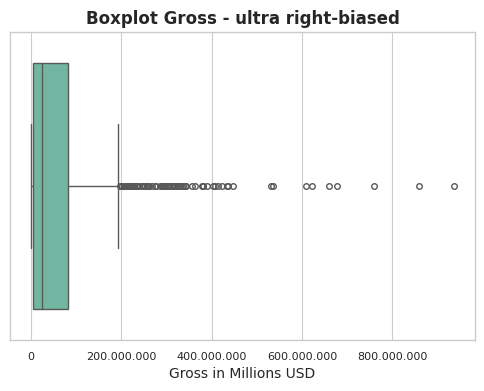

In [197]:
sns.boxplot(x=df['Gross'])
plt.title('Boxplot Gross - ultra right-biased')
plt.xlabel('Gross in Millions USD')

# Convert X-axis to readable scale
ax = plt.gca()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

plt.show()


In [198]:
# Star Power: Calculate for each actor:
    # Number of film
    # Average rating of those films
    # Average gross

# Convert to analitic long format [ movie + actor ]
stars_long = df.melt(
    id_vars=['Series_Title', 'IMDB_Rating', 'Gross'],
    value_vars=['Star1', 'Star2', 'Star3', 'Star4'],
    var_name='star_position',
    value_name='star'
).drop_duplicates(subset=['Series_Title','star'])   #Clean up possible duplicates

# Ensure 'Gross' column in stars_long is numeric before aggregation
# This step converts to string to handle potential mixed types and then removes commas,
# finally coercing to numeric, turning any unparseable values into NaN.
stars_long['Gross'] = pd.to_numeric(stars_long['Gross'].astype(str).str.replace(',', '', regex=True), errors='coerce')

# dataframe added (real Star Power)
star_power = (
    stars_long
    .groupby('star')
    .agg(
        movie_count=('Series_Title', 'count'),
        avg_rating=('IMDB_Rating', 'mean'),
        avg_gross=('Gross', 'mean')   # mean() already ignores NaN by default
    )
    .reset_index()
)

# Scale avg_gross to millions of USD
star_power['avg_gross_millions'] = star_power['avg_gross'] / 1_000_000


#Filter actors with very few films
star_power = star_power[star_power['movie_count'] >= 3]

star_power.head()   #check


,star,movie_count,avg_rating,avg_gross,avg_gross_millions
1,Aamir Khan,8,8.237500,4.761731e+06,4.761731
15,Adrien Brody,3,8.100000,3.058136e+07,30.581357
32,Akshay Kumar,5,8.060000,1.001295e+06,1.001295
35,Al Pacino,13,8.076923,4.932403e+07,49.324030
39,Alan Arkin,3,7.733333,5.476716e+07,54.767157


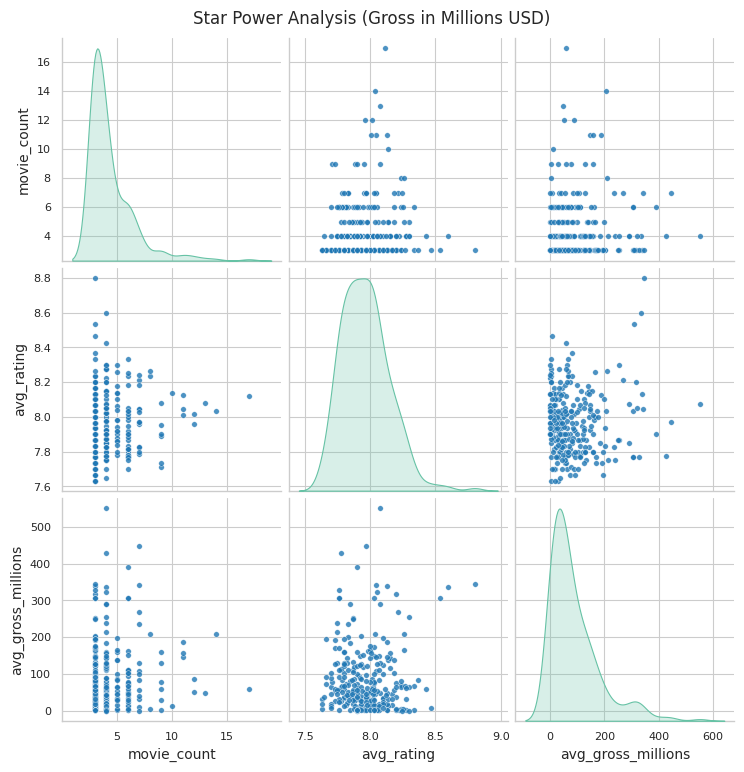

In [199]:
#Pairplot
sns.pairplot(
    star_power,
    vars=['movie_count', 'avg_rating', 'avg_gross_millions'],
    diag_kind='kde',
     plot_kws={'color': '#1f77b4', 'alpha': 0.8}
)
plt.suptitle("Star Power Analysis (Gross in Millions USD)", y=1.02, fontsize=12)
plt.show()


7. Box Plot of Genres vs. Ratings:

* Visualize the distribution of IMDB_Rating across different Genres using a Seaborn box plot.

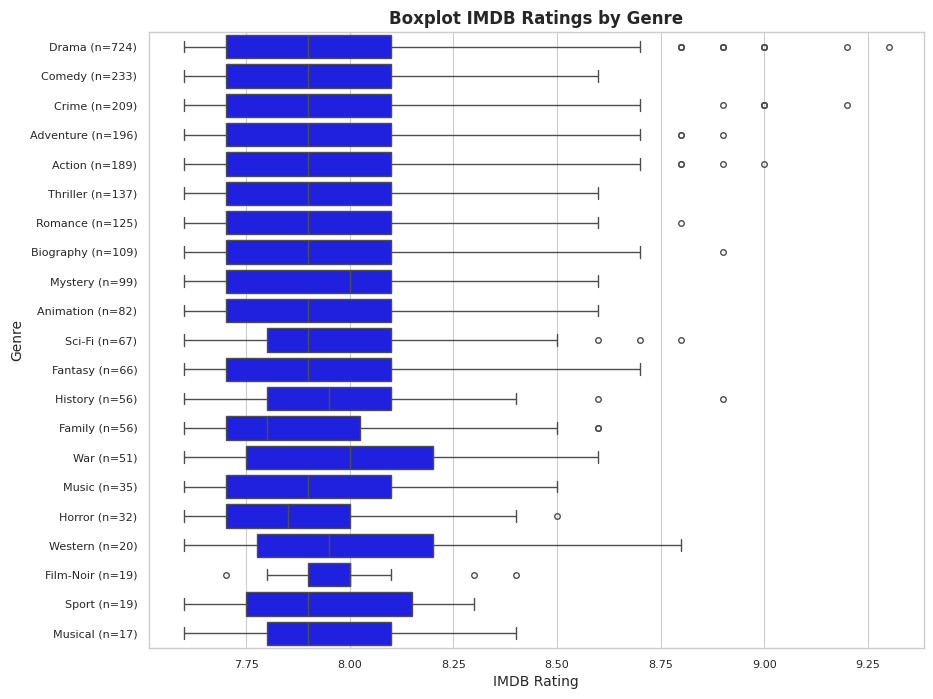

In [200]:
# Prepare data
df_genres = df[['Series_Title', 'Genre', 'IMDB_Rating']].copy()
df_genres = df_genres.assign(Genre=df_genres['Genre'].str.split(', ')).explode('Genre')

# Count n by gender and order
genre_counts = df_genres['Genre'].value_counts()
ordered_genres = genre_counts.index

plt.figure(figsize=(10,8))
ax = sns.boxplot(
    y='Genre',
    x='IMDB_Rating',
    data=df_genres,
    order=ordered_genres,
    color='blue'
)

# Set ticks and labels with n
ax.set_yticks(range(len(ordered_genres)))
ax.set_yticklabels([f"{genre} (n={genre_counts[genre]})" for genre in ordered_genres])

plt.xlabel("IMDB Rating")
plt.ylabel("Genre")
plt.title("Boxplot IMDB Ratings by Genre")
plt.show()


8. Correlation Heatmap:

* Create a heatmap using Seaborn to identify correlations between numerical columns like IMDB_Rating, Meta_score, No_of_votes, and Gross.

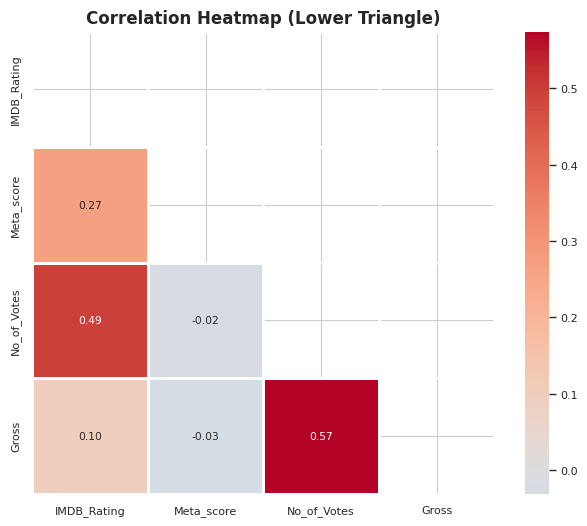

In [201]:
# Numeric columns
numeric_cols = ['IMDB_Rating', 'Meta_score', 'No_of_Votes', 'Gross']
df_corr = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = df_corr.corr()

# Heatmap with only lower triangle visible
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),  # mask for the top triangle
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=1,
    square=True
)
plt.title("Correlation Heatmap (Lower Triangle)", fontsize=12)
plt.show()